In [1]:
pip install pandas scikit-learn sentence-transformers matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd

with open("sample_logs.txt", "r") as f:
    logs = f.readlines()

print("Total logs:", len(logs))

Total logs: 5200


In [6]:
import re 
parsed_logs = []

pattern = r'(\w+\s+\d+\s+\d+:\d+:\d+)\s+([\w\-]+)\s+([\w\-\[\]]+):\s+<(\w+)>\s+(.*)'

for log in logs:
    match = re.match(pattern, log)
    
    if match:
        timestamp = match.group(1)
        host = match.group(2)
        service = match.group(3)
        level = match.group(4)
        message = match.group(5)

        parsed_logs.append({
            "timestamp": timestamp,
            "host": host,
            "service": service,
            "level": level,
            "message": message
        })

df = pd.DataFrame(parsed_logs)

In [7]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = model.encode(df["message"].tolist())

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [8]:
print(len(embeddings))
print(embeddings.shape)

747
(747, 384)


In [9]:
import re

def clean_log(msg):
    msg = re.sub(r'\d+', 'NUM', msg)
    msg = re.sub(r'uid=\w+', 'uid=USER', msg)
    msg = re.sub(r'sku=\w+', 'sku=ITEM', msg)
    return msg

df["message"] = df["message"].apply(clean_log)

from sklearn.cluster import DBSCAN

In [10]:
from sklearn.cluster import DBSCAN

clustering = DBSCAN(
    eps=0.45,
    min_samples=10,
    metric="cosine"
)

labels = clustering.fit_predict(embeddings)

df["cluster"] = labels

df["cluster"].value_counts()

cluster
 2     203
 4      97
 8      89
 0      60
 7      60
-1      53
 9      27
 12     26
 11     25
 1      23
 3      23
 5      15
 10     12
 13     12
 6      11
 14     11
Name: count, dtype: int64

In [11]:
for cluster_id in df["cluster"].unique():

    if cluster_id == -1:
        print("\nANOMALIES")
    else:
        print(f"\nCluster {cluster_id}")

    examples = df[df["cluster"] == cluster_id]["message"].head(3)

    for e in examples:
        print("-", e)


Cluster 0
- Health check passed upstream=auth-service
- Health check passed upstream=auth-service
- Health check passed upstream=inventory

Cluster 1
- Inventory sync completed source=ERP records=NUM duration=NUM.NUMs
- Sync delay from ERP: last update NUM minutes ago
- Inventory sync completed source=ERP records=NUM duration=NUM.NUMs

Cluster 2
- MFA verification passed uid=USER
- Login attempt with expired token uid=USER
- MFA verification failed uid=USER code=INVALID

ANOMALIES
- Payment gateway returned HTTP NUM endpoint=api.stripe.internal/vNUM/charges
- Warehouse API unreachable warehouse=WH-NUM error=ECONNREFUSED
- Deadlock detected on transactions table, rolling back txn=txn-NUM

Cluster 3
- Shipment received shipment_id=SHP-NUM items=NUM
- Shipment received shipment_id=SHP-NUM items=NUM
- Shipment received shipment_id=SHP-NUM items=NUM

Cluster 4
- Request failed method=POST path=/api/vNUM/checkout status=NUM duration=NUMms error="internal server error"
- Request completed me

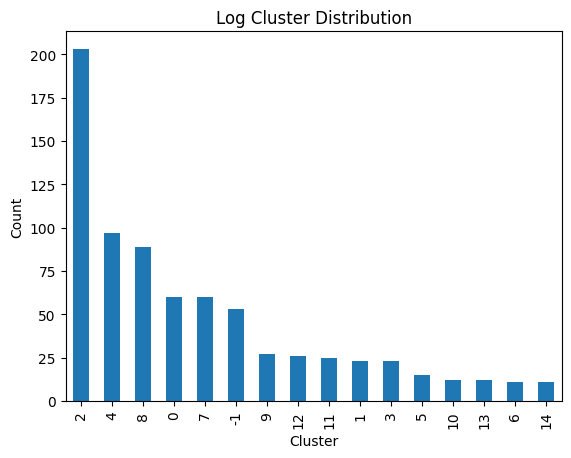

In [12]:
import matplotlib.pyplot as plt

cluster_counts = df["cluster"].value_counts()

cluster_counts.plot(kind="bar")

plt.title("Log Cluster Distribution")
plt.xlabel("Cluster")
plt.ylabel("Count")

plt.show()

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

reduced = pca.fit_transform(embeddings)

plt.figure()

plt.scatter(
    reduced[:,0],
    reduced[:,1],
    c=df["cluster"],
)

plt.title("Log Embedding Clusters")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.show()

In [ ]:
colors = ["red" if c == -1 else "blue" for c in df["cluster"]]

plt.figure()

plt.scatter(
    reduced[:,0],
    reduced[:,1],
    c=colors
)

plt.title("Anomaly Detection in Logs")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.show()

In [ ]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)

tsne_results = tsne.fit_transform(embeddings)

plt.figure()

scatter = plt.scatter(
    tsne_results[:,0],
    tsne_results[:,1],
    c=df["cluster"]
)

plt.colorbar(scatter, label="Cluster ID")

plt.title("Log Clusters Visualized with t-SNE")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")

plt.show()

In [14]:
print("===== Log Analysis Summary =====")

print("Total logs processed:", len(df))
print("Clusters detected:", df["cluster"].nunique())

# Ensure anomalies is defined (cluster -1 means noise for DBSCAN)
if 'anomalies' not in globals():
    anomalies = df[df["cluster"] == -1]

print("Anomalies detected:", len(anomalies))

===== Log Analysis Summary =====
Total logs processed: 747
Clusters detected: 16
Anomalies detected: 53


In [16]:
# Ensure we have a cluster_summary to display
if 'cluster_summary' not in globals():
    cluster_summary = (
        df.groupby('cluster')[['cluster', 'message']]
          .head(5)
          .reset_index(drop=True)
    )

# Ensure anomalies exists (DBSCAN uses -1 for noise)
if 'anomalies' not in globals():
    anomalies = df[df['cluster'] == -1]

display(cluster_summary)
display(anomalies.head(20))

,cluster,message
0,0,Health check passed upstream=auth-service
1,1,Inventory sync completed source=ERP records=NU...
2,2,MFA verification passed uid=USER
3,2,Login attempt with expired token uid=USER
4,-1,Payment gateway returned HTTP NUM endpoint=api...
...,...,...
75,14,Cron job failed job=nightly_backup error=disk_...
76,14,Cron job failed job=nightly_backup error=disk_...
77,6,Invoice generated invoice_id=INV-NUM
78,6,Invoice generated invoice_id=INV-NUM


,timestamp,host,service,level,message,cluster
4,Mar 15 06:01:14,prod-web-01,payment-svc[9307],ERROR,Payment gateway returned HTTP NUM endpoint=api...,-1
25,Mar 15 06:06:43,prod-web-02,inventory[1427],ERROR,Warehouse API unreachable warehouse=WH-NUM err...,-1
72,Mar 15 06:17:53,prod-web-02,payment-svc[6304],ERROR,"Deadlock detected on transactions table, rolli...",-1
89,Mar 15 06:24:56,prod-db-01,inventory[7265],ERROR,Warehouse API unreachable warehouse=WH-NUM err...,-1
96,Mar 15 06:27:09,prod-web-02,payment-svc[4746],ERROR,"Deadlock detected on transactions table, rolli...",-1
98,Mar 15 06:27:43,prod-web-01,auth-service[9121],ERROR,Token signing key rotation failed: keystore lo...,-1
100,Mar 15 06:28:04,prod-web-02,payment-svc[3996],ERROR,"Deadlock detected on transactions table, rolli...",-1
141,Mar 15 06:38:33,prod-web-02,scheduler[5125],WARN,"Job queue backlog: NUM jobs pending, oldest=NU...",-1
224,Mar 15 06:56:38,prod-web-01,inventory[3855],ERROR,Warehouse API unreachable warehouse=WH-NUM err...,-1
225,Mar 15 06:56:38,prod-web-01,inventory[3634],ERROR,Warehouse API unreachable warehouse=WH-NUM err...,-1


In [ ]:
import pandas as pd
pd.set_option("display.max_rows", None)

df_display = df[["service", "level", "message", "cluster"]].copy()

df_display

,service,level,message,cluster
0,api-gateway[3330],INFO,Health check passed upstream=auth-service,0
1,inventory[4727],INFO,Inventory sync completed source=ERP records=NU...,1
2,auth-service[5564],INFO,MFA verification passed uid=USER,2
3,auth-service[8354],WARN,Login attempt with expired token uid=USER,2
4,payment-svc[9307],ERROR,Payment gateway returned HTTP NUM endpoint=api...,-1
5,auth-service[6962],ERROR,MFA verification failed uid=USER code=INVALID,2
6,inventory[5670],INFO,Shipment received shipment_id=SHP-NUM items=NUM,3
7,api-gateway[9234],ERROR,Request failed method=POST path=/api/vNUM/chec...,4
8,api-gateway[8912],ERROR,TLS handshake failed client_ip=NUM.NUM.NUM.NUM...,5
9,api-gateway[1828],INFO,Request completed method=POST path=/api/vNUM/o...,4


In [18]:
def highlight_logs(row):
    if row["cluster"] == -1:
        return ["background-color: #e81e1e"] * len(row)
    elif row["level"] == "ERROR":
        return ["background-color: #ffa500; color: black"] * len(row)
    else:
        return [""] * len(row)
    
df_display.style.apply(highlight_logs, axis=1)    

NameError: name 'df_display' is not defined

In [ ]:
from collections import Counter
import pandas as pd

anomalies = df[df["cluster"] == -1]["message"]

counter = Counter(anomalies)

# Convert to DataFrame
anomaly_df = pd.DataFrame(counter.items(), columns=["message", "count"])

# Sort by frequency
anomaly_df = anomaly_df.sort_values(by="count", ascending=False).reset_index(drop=True)
anomaly_df.index = anomaly_df.index + 1
anomaly_df.head(10)
pd.set_option('display.max_colwidth', None)

anomaly_df.style.set_properties(subset=["message"], **{
    "white-space": "pre-wrap"
})

In [ ]:
# Total anomalies
total_anomalies = anomaly_df['count'].sum()

# Number of unique anomaly types
unique_anomalies = anomaly_df.shape[0]

# Most frequent anomaly
top_anomaly = anomaly_df.loc[anomaly_df['count'].idxmax()]

print("📊 LOG SUMMARY")
print("-" * 50)
print(f"Total anomalies detected: {total_anomalies}")
print(f"Unique anomaly types: {unique_anomalies}")
print(f"Most frequent issue: {top_anomaly['message']}")
print(f"Occurrences: {top_anomaly['count']}")

In [ ]:
def classify_severity(message):
    message = message.lower()
    
    if "timeout" in message or "unreachable" in message:
        return "Critical"
    elif "failed" in message or "error" in message:
        return "Moderate"
    elif "slow" in message or "latency" in message:
        return "Warning"
    else:
        return "Low"

# Apply to anomaly_df
anomaly_df['severity'] = anomaly_df['message'].apply(classify_severity)

anomaly_df.head()